In [1]:
using JSON, VegaLite, Query, Dates, DataFrames, CSVFiles


(process:65228): GLib-GIO-WARNING **: 16:57:47.600: Failed to open application manifest `C:\Users\david\source\juliaup\AppxManifest.xml' for package #28 (`StringBuildersManifest_1.0.0.6_neutral__b4b9g9e7g86aw'): error code 0x2


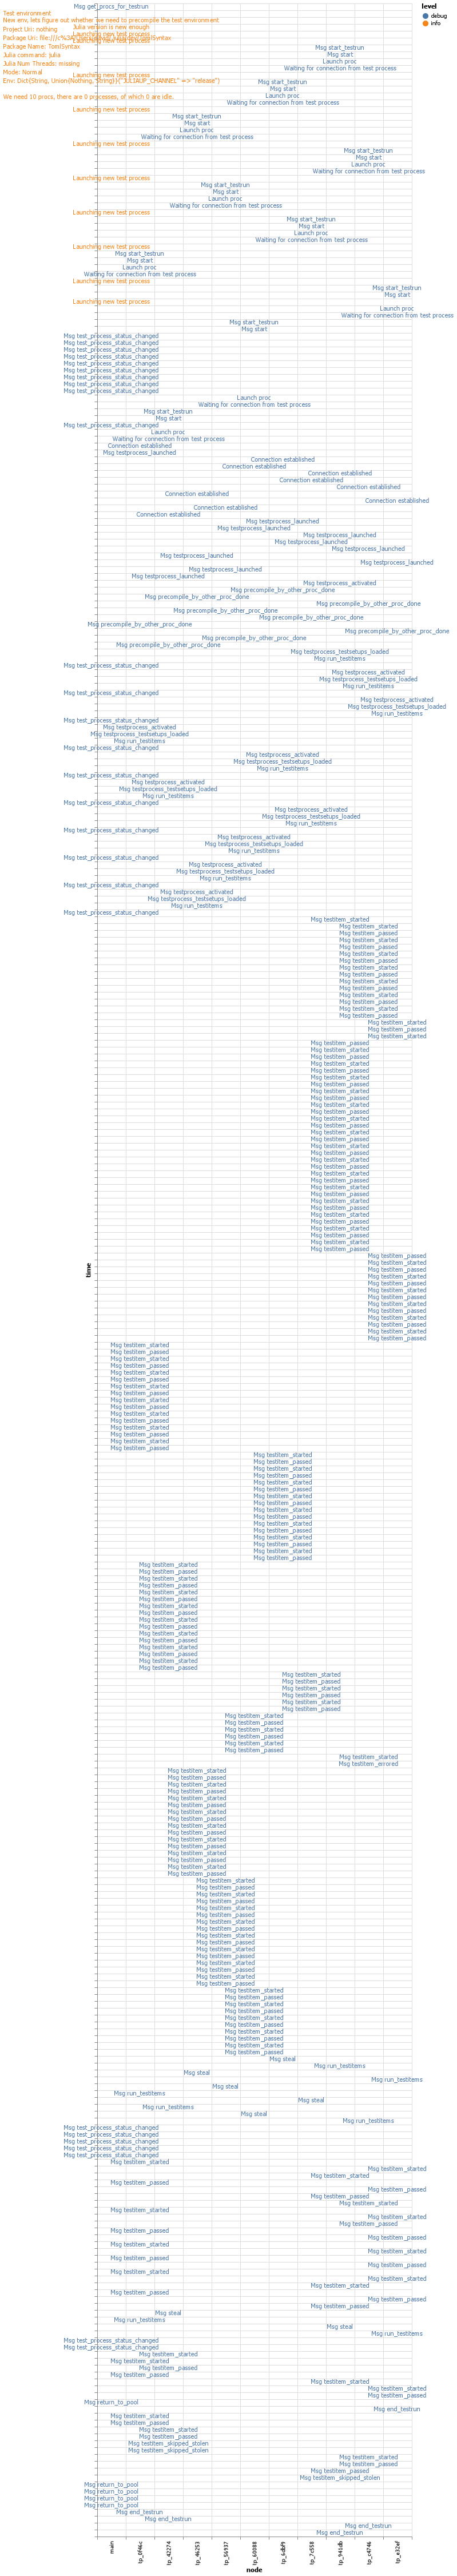

In [37]:
function format_kw(kwargs)
    kwargs = kwargs |> @filter(!in(_.first, ("timestamp", "node"))) |> Dict

    if length(kwargs) == 0
        return ""
    else
        return ["$k: $v" for (k,v) in kwargs]
    end
end

x = readlines("tic.log.json") |>
@map(JSON.parse(_)) |>
@map({msg=_["msg"], level=_[ "level"], kw=_["kwargs"]}) |>
@filter(!contains(_.msg, "append") && !contains(_.msg, "testprocess_output")) |>
@mutate(time=_.kw["timestamp"], node=_.kw["node"], kwargs=format_kw(_.kw)) |>
@select(-:kw) |>
DataFrame |>
@vlplot(
    mark=:text,    
    x = {"node:n", axis={grid=true, tickBand=:extent}},
    y = {"time:o", axis={grid=true, labels=false, tickBand=:extent}},
    color = :level,
    opacity={
        condition={param=:level_sel, value=1},
        value=0.1
    },
    text=:msg,
    tooltip = :kwargs,
    height={step=12},
    width={step=50},
    params=[
        {name=:level_sel, select={type=:point, fields=[:level]}, bind=:legend},        
    ],
)
